In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import(
LabelEncoder,
OneHotEncoder,
OrdinalEncoder,
TargetEncoder,
StandardScaler,
MinMaxScaler,
RobustScaler,
MaxAbsScaler
)

In [3]:
df = pd.read_csv('ds_salaries.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [5]:
df.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


In [6]:
df.sample(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
2153,2022,SE,FT,ML Engineer,183000,USD,183000,US,100,US,M
2000,2022,EX,FT,Data Scientist,130000,USD,130000,US,100,US,M
941,2023,SE,FT,Analytics Engineer,120000,USD,120000,US,0,US,M
203,2023,EX,FT,Data Engineer,220000,USD,220000,US,0,US,M
704,2023,MI,FT,Data Analyst,85000,USD,85000,US,0,US,M


In [7]:
df.shape

(3755, 11)

In [8]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [10]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [11]:
df.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


In [12]:
df.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [13]:
df.isna().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(1171)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print("-"*50)

work_year
4
[2023 2022 2020 2021]
--------------------------------------------------
experience_level
4
['SE' 'MI' 'EN' 'EX']
--------------------------------------------------
employment_type
4
['FT' 'CT' 'FL' 'PT']
--------------------------------------------------
job_title
93
['Principal Data Scientist' 'ML Engineer' 'Data Scientist'
 'Applied Scientist' 'Data Analyst' 'Data Modeler' 'Research Engineer'
 'Analytics Engineer' 'Business Intelligence Engineer'
 'Machine Learning Engineer' 'Data Strategist' 'Data Engineer'
 'Computer Vision Engineer' 'Data Quality Analyst'
 'Compliance Data Analyst' 'Data Architect'
 'Applied Machine Learning Engineer' 'AI Developer' 'Research Scientist'
 'Data Analytics Manager' 'Business Data Analyst' 'Applied Data Scientist'
 'Staff Data Analyst' 'ETL Engineer' 'Data DevOps Engineer' 'Head of Data'
 'Data Science Manager' 'Data Manager' 'Machine Learning Researcher'
 'Big Data Engineer' 'Data Specialist' 'Lead Data Analyst'
 'BI Data Engineer' 'Dire

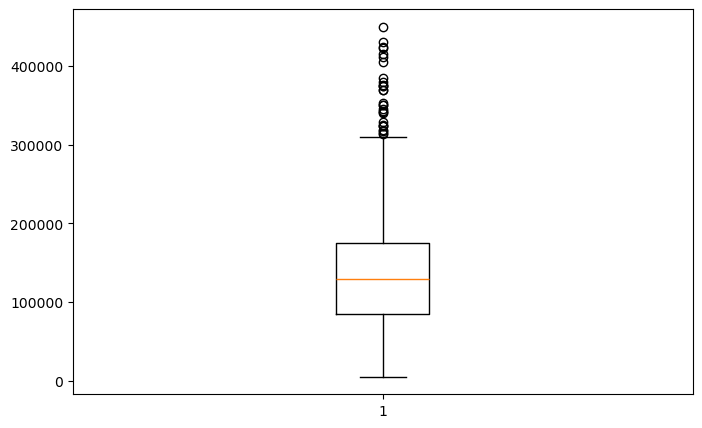

In [28]:
plt.figure(figsize=(8,5))
plt.boxplot(df['salary_in_usd'])
plt.show()

In [30]:
Q1 = df['salary_in_usd'].quantile(.25)
Q3 = df['salary_in_usd'].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['salary_in_usd']< lower) | (df['salary_in_usd']> upper)]
outliers

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
33,2023,SE,FT,Computer Vision Engineer,342810,USD,342810,US,0,US,M
133,2023,SE,FT,Machine Learning Engineer,342300,USD,342300,US,0,US,L
145,2023,SE,FT,Machine Learning Engineer,318300,USD,318300,US,100,US,M
228,2023,EX,FT,Head of Data,329500,USD,329500,US,0,US,M
478,2023,EX,FT,Director of Data Science,353200,USD,353200,US,0,US,M
488,2023,SE,FT,Data Scientist,317070,USD,317070,US,0,US,M
528,2023,SE,FT,AI Scientist,1500000,ILS,423834,IL,0,IL,L
649,2023,SE,FT,Data Architect,376080,USD,376080,US,100,US,M
845,2023,MI,FT,Research Scientist,340000,USD,340000,US,100,US,M
1105,2023,SE,FT,Data Scientist,370000,USD,370000,US,0,US,M


In [31]:
outliers.shape

(29, 11)

In [36]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


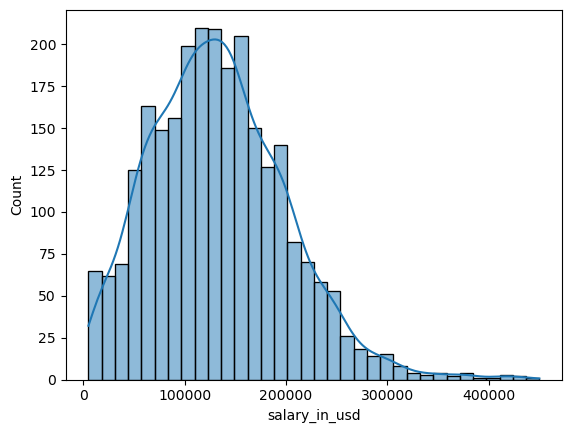

In [34]:
sns.histplot(df['salary_in_usd'], kde=True)
plt.show()

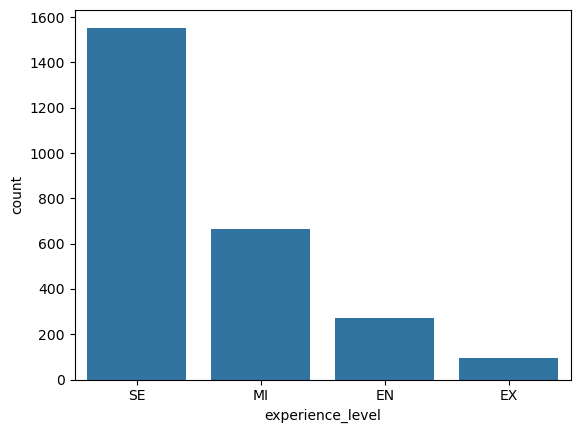

In [38]:
sns.countplot(x='experience_level', data=df)
plt.show()

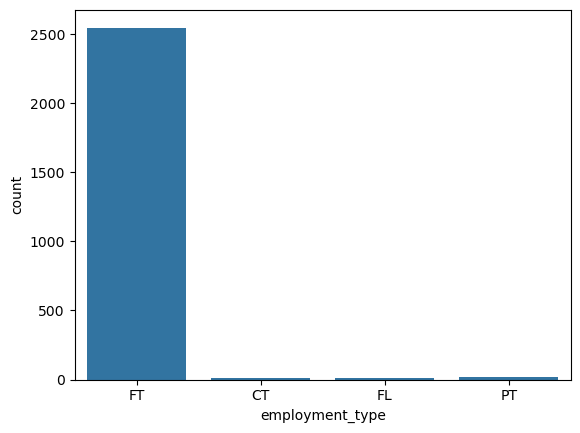

In [40]:
sns.countplot(x='employment_type', data=df)
plt.show()

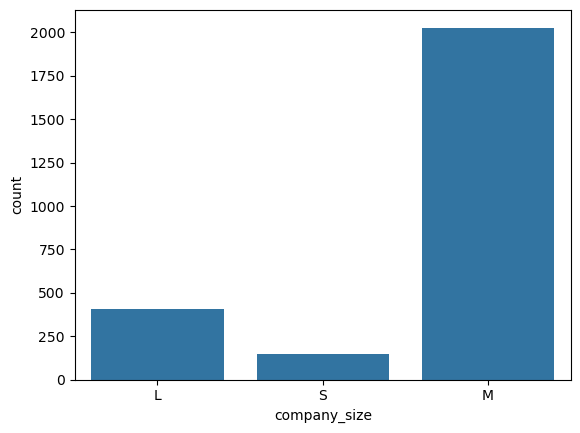

In [42]:
sns.countplot(x='company_size', data=df)
plt.show()

In [43]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

<Axes: xlabel='experience_level', ylabel='salary_in_usd'>

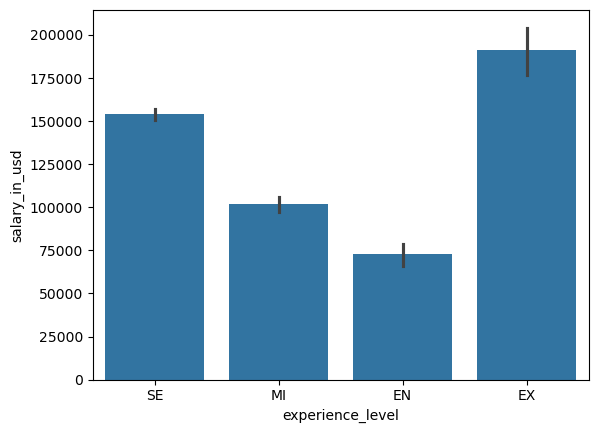

In [44]:
sns.barplot(x='experience_level', y='salary_in_usd', data=df)

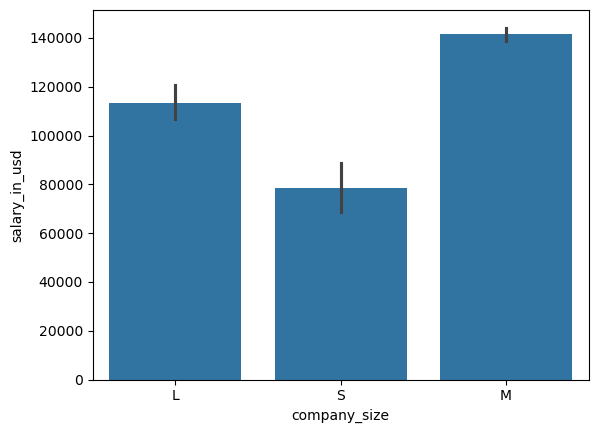

In [45]:
sns.barplot(x='company_size', y='salary_in_usd', data=df)
plt.show()